# Salary Prediction using Ensemble Learning

This Model predicts salary using five employee features:

- Age
- Gender
- Education Level
- Job Title
- Years of Experience

two ensemble models used **Random Forest Regressor** (bagging)
and **Gradient Boosting Regressor** (boosting).

## 1. Import required libraries


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## 2. Load the supplied dataset

In [2]:
BASE_DIR = Path.cwd()
if not (BASE_DIR / "data" / "Salary_Data.csv").exists():
    BASE_DIR = BASE_DIR.parent

DATA_PATH = BASE_DIR / "data" / "Salary_Data.csv"
MODELS_DIR = BASE_DIR / "models"
OUTPUTS_DIR = BASE_DIR / "outputs"

MODELS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

raw_data = pd.read_csv(DATA_PATH)
raw_data.columns = [
    column.strip().lstrip("\ufeff")
    for column in raw_data.columns
]

print("Raw dataset shape:", raw_data.shape)
raw_data.head()

Raw dataset shape: (6704, 6)


    Age  Gender  ... Years of Experience    Salary
0  32.0    Male  ...                 5.0   90000.0
1  28.0  Female  ...                 3.0   65000.0
2  45.0    Male  ...                15.0  150000.0
3  36.0  Female  ...                 7.0   60000.0
4  52.0    Male  ...                20.0  200000.0

[5 rows x 6 columns]

## 3. Inspect and clean the data



In [3]:
required_columns = [
    "Age",
    "Gender",
    "Education Level",
    "Job Title",
    "Years of Experience",
    "Salary",
]

print("Missing values:")
print(raw_data[required_columns].isnull().sum())
print("\nExact duplicate rows:", raw_data.duplicated().sum())

Missing values:
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

Exact duplicate rows: 4912


In [4]:
data = raw_data[required_columns].dropna().copy()

data["Education Level"] = data["Education Level"].replace(
    {
        "Bachelor's": "Bachelor's Degree",
        "Master's": "Master's Degree",
        "phD": "PhD",
    }
)

for column in ["Gender", "Education Level", "Job Title"]:
    data[column] = data[column].astype(str).str.strip()

data = data[
    (data["Age"] >= 18)
    & (data["Years of Experience"] >= 0)
    & (data["Salary"] >= 10000)
]

data = data.drop_duplicates().reset_index(drop=True)

print("Clean dataset shape:", data.shape)
data.head()

Clean dataset shape: (1782, 6)


    Age  Gender  ... Years of Experience    Salary
0  32.0    Male  ...                 5.0   90000.0
1  28.0  Female  ...                 3.0   65000.0
2  45.0    Male  ...                15.0  150000.0
3  36.0  Female  ...                 7.0   60000.0
4  52.0    Male  ...                20.0  200000.0

[5 rows x 6 columns]

In [5]:
data.describe(include="all").T

                      count unique  ...       75%       max
Age                  1782.0    NaN  ...      41.0      62.0
Gender                 1782      3  ...       NaN       NaN
Education Level        1782      4  ...       NaN       NaN
Job Title              1782    191  ...       NaN       NaN
Years of Experience  1782.0    NaN  ...      13.0      34.0
Salary               1782.0    NaN  ...  160000.0  250000.0

[6 rows x 11 columns]

## 4. Visualise salary patterns

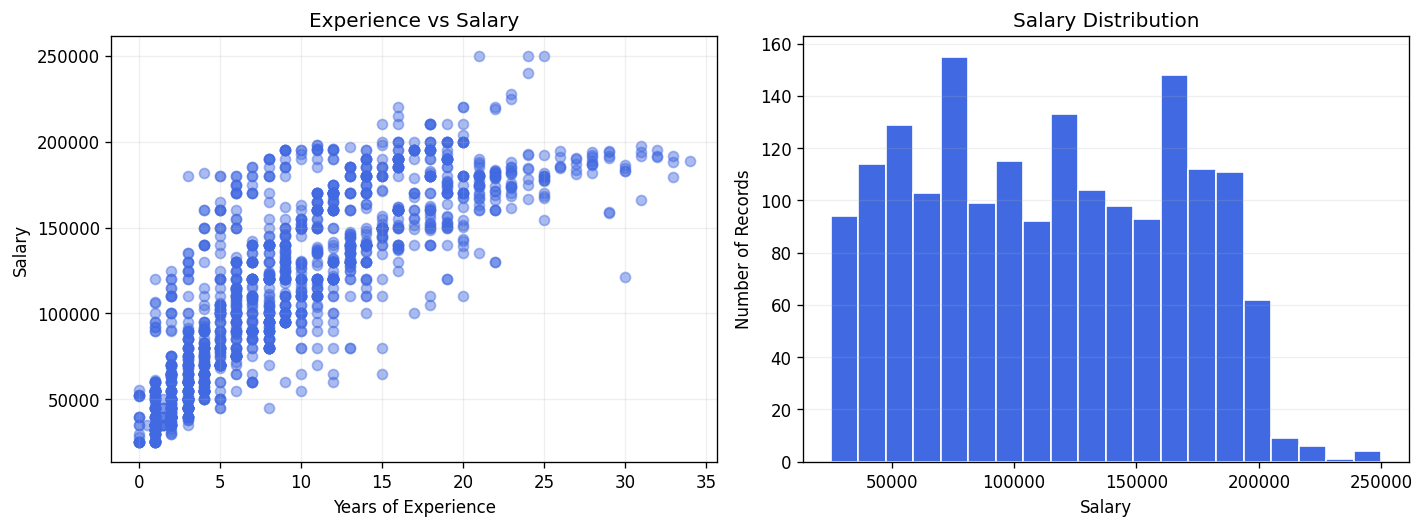

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(
    data["Years of Experience"],
    data["Salary"],
    color="royalblue",
    alpha=0.45,
)
axes[0].set_title("Experience vs Salary")
axes[0].set_xlabel("Years of Experience")
axes[0].set_ylabel("Salary")
axes[0].grid(alpha=0.20)

axes[1].hist(
    data["Salary"],
    bins=20,
    color="royalblue",
    edgecolor="white",
)
axes[1].set_title("Salary Distribution")
axes[1].set_xlabel("Salary")
axes[1].set_ylabel("Number of Records")
axes[1].grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

## 5. Select input features and target



In [7]:
feature_columns = [
    "Age",
    "Gender",
    "Education Level",
    "Job Title",
    "Years of Experience",
]

numerical_columns = ["Age", "Years of Experience"]
categorical_columns = ["Gender", "Education Level", "Job Title"]

X = data[feature_columns]
y = data["Salary"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (1782, 5)
Target shape: (1782,)


## 6. Create preprocessing



In [8]:
def create_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("numerical", "passthrough", numerical_columns),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_columns,
            ),
        ]
    )

## 7. Create the 80:20 train-test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1425
Testing rows: 357


## 8. Random Forest Regressor



In [10]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", create_preprocessor()),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_grid = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [None, 15],
    "model__min_samples_leaf": [1, 2],
}

random_forest_search = GridSearchCV(
    random_forest_pipeline,
    random_forest_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

random_forest_search.fit(X_train, y_train)
random_forest_model = random_forest_search.best_estimator_

print("Best Random Forest parameters:")
print(random_forest_search.best_params_)

Best Random Forest parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 250}


## 9. Train Gradient Boosting Regressor


In [11]:
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", create_preprocessor()),
        ("model", GradientBoostingRegressor(random_state=42)),
    ]
)

gradient_boosting_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.10],
    "model__max_depth": [2, 3],
}

gradient_boosting_search = GridSearchCV(
    gradient_boosting_pipeline,
    gradient_boosting_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

gradient_boosting_search.fit(X_train, y_train)
gradient_boosting_model = gradient_boosting_search.best_estimator_

print("Best Gradient Boosting parameters:")
print(gradient_boosting_search.best_params_)

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


## 10. Evaluate both models

In [12]:
def evaluate_model(model_name, model, actual_features, actual_salary):
    predictions = model.predict(actual_features)
    mse = mean_squared_error(actual_salary, predictions)

    return {
        "Model": model_name,
        "MAE": mean_absolute_error(actual_salary, predictions),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2_Score": r2_score(actual_salary, predictions),
        "Predictions": predictions,
    }


forest_result = evaluate_model(
    "Random Forest Regressor",
    random_forest_model,
    X_test,
    y_test,
)

boosting_result = evaluate_model(
    "Gradient Boosting Regressor",
    gradient_boosting_model,
    X_test,
    y_test,
)

comparison = pd.DataFrame(
    [
        {
            key: value
            for key, value in result.items()
            if key != "Predictions"
        }
        for result in [forest_result, boosting_result]
    ]
)

comparison.round(4)

                         Model         MAE           MSE        RMSE  R2_Score
0      Random Forest Regressor  10059.4132  2.509687e+08  15841.9901    0.9047
1  Gradient Boosting Regressor  12295.6422  2.998183e+08  17315.2619    0.8862

In [13]:
result_table = X_test.copy()
result_table["Actual Salary"] = y_test
result_table["Random Forest Prediction"] = forest_result["Predictions"]
result_table["Gradient Boosting Prediction"] = boosting_result["Predictions"]
result_table.head(10)

       Age  Gender  ... Random Forest Prediction Gradient Boosting Prediction
824   52.0    Male  ...            185250.531200                190661.522496
1471  33.0    Male  ...            137316.268667                135363.294781
233   32.0    Male  ...             43880.000000                 52999.926369
798   28.0    Male  ...             92137.817019                 90892.658760
777   22.0  Female  ...             45157.392000                 54253.578912
270   44.0  Female  ...            148783.552000                149179.101010
416   24.0    Male  ...            102418.158730                102721.020274
1435  33.0  Female  ...            125093.176667                107502.869899
1345  34.0  Female  ...            113205.653600                112717.724103
111   37.0    Male  ...            101895.372000                110177.550779

[10 rows x 8 columns]

## 11. Plot actual and predicted salary values

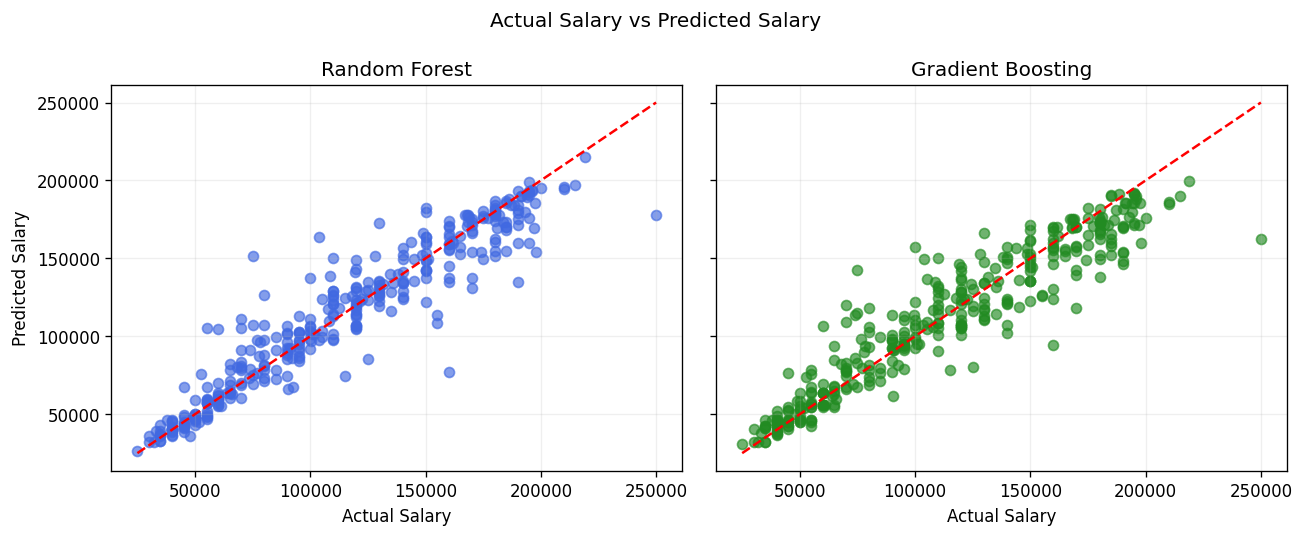

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

axes[0].scatter(
    y_test,
    forest_result["Predictions"],
    color="royalblue",
    alpha=0.65,
)
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Actual Salary")
axes[0].set_ylabel("Predicted Salary")

axes[1].scatter(
    y_test,
    boosting_result["Predictions"],
    color="forestgreen",
    alpha=0.65,
)
axes[1].set_title("Gradient Boosting")
axes[1].set_xlabel("Actual Salary")

minimum_value = min(
    y_test.min(),
    *forest_result["Predictions"],
    *boosting_result["Predictions"],
)
maximum_value = max(
    y_test.max(),
    *forest_result["Predictions"],
    *boosting_result["Predictions"],
)

for axis in axes:
    axis.plot(
        [minimum_value, maximum_value],
        [minimum_value, maximum_value],
        color="red",
        linestyle="--",
    )
    axis.grid(alpha=0.20)

plt.suptitle("Actual Salary vs Predicted Salary")
plt.tight_layout()
plt.show()

## 12. Retrain and save pipelines



In [15]:
final_random_forest_model = clone(random_forest_model)
final_random_forest_model.fit(X, y)

final_gradient_boosting_model = clone(gradient_boosting_model)
final_gradient_boosting_model.fit(X, y)

forest_model_path = MODELS_DIR / "random_forest_model.joblib"
boosting_model_path = MODELS_DIR / "gradient_boosting_model.joblib"

joblib.dump(final_random_forest_model, forest_model_path)
joblib.dump(final_gradient_boosting_model, boosting_model_path)

print("Saved:", forest_model_path)
print("Saved:", boosting_model_path)

Saved: /workspace/scratch/8609934740e7/Salary_Prediction_Ensemble_Learning/models/random_forest_model.joblib
Saved: /workspace/scratch/8609934740e7/Salary_Prediction_Ensemble_Learning/models/gradient_boosting_model.joblib


## 13. Testing saved pipeline with one employee

In [16]:
loaded_model = joblib.load(forest_model_path)

new_employee = pd.DataFrame(
    {
        "Age": [32],
        "Gender": ["Male"],
        "Education Level": ["Bachelor's Degree"],
        "Job Title": ["Software Engineer"],
        "Years of Experience": [5.0],
    }
)

predicted_salary = loaded_model.predict(new_employee)[0]

print("Input employee:")
print(new_employee.to_string(index=False))
print(f"\nPredicted salary: {predicted_salary:,.0f}")

Input employee:
 Age Gender   Education Level         Job Title  Years of Experience
  32   Male Bachelor's Degree Software Engineer                  5.0

Predicted salary: 86,633
